### Предисловие

С SQL все максимально знакомо, тут нейронки не использовал для решения. 

Кроме 8 задания. С рекурсией ни разу не сталкивался, но в итоге разобрал механику, комменты больше для себя оставил.

-----

### Задача №1. 
Задача: Напишите запрос, объединяющий две таблицы `orders` и `customers`, возвращающий имена клиентов (`customer_name`) и сумму заказов (`order_total`), при условии, что заказ сделан клиентом старше 30 лет.

Таблицы:

```sql
CREATE TABLE customers (
    customer_id INT PRIMARY KEY,
    customer_name VARCHAR(100),
    age INT
);

CREATE TABLE orders (
    order_id INT PRIMARY KEY,
    customer_id INT,
    order_total DECIMAL(10, 2)
);
```

### Решение

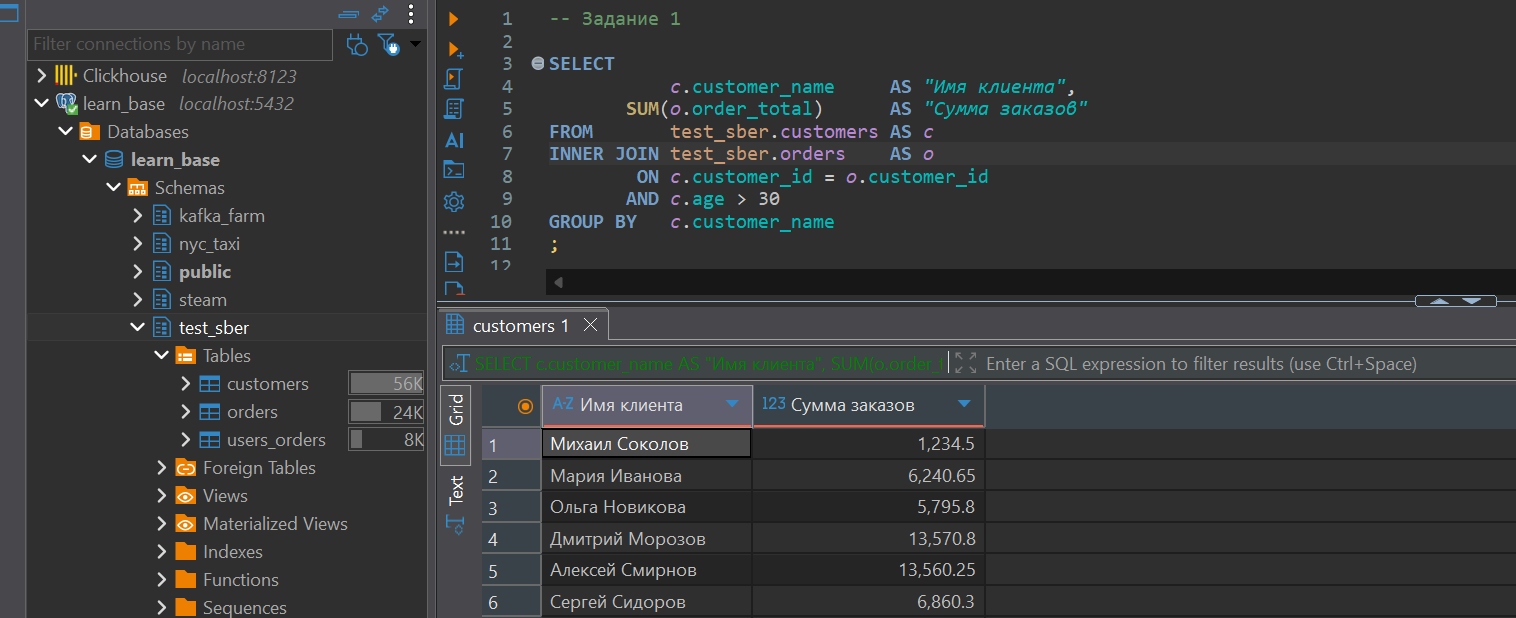

### Задача №2. 
Задача: Найдите всех пользователей, которые сделали больше трех заказов суммарно, отсортировав результат по количеству заказов в порядке убывания.

Таблица:
```sql
CREATE TABLE users_orders (
    user_id INT,
    order_date DATE,
    amount DECIMAL(10, 2)
);
```

### Решение

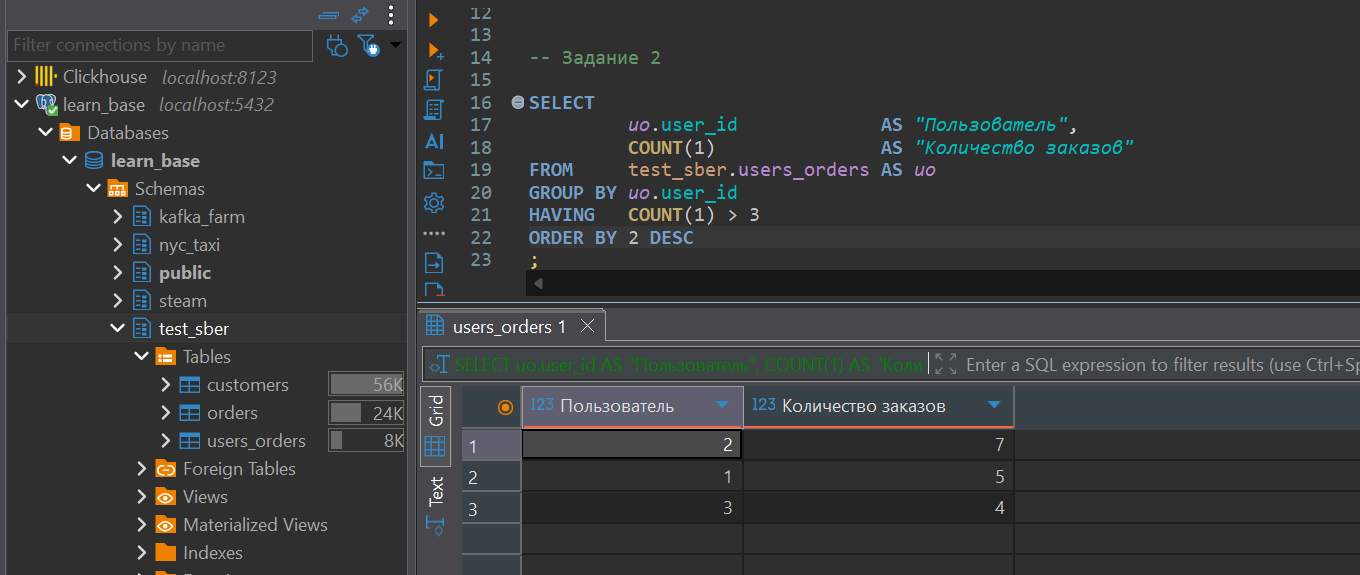

### Задача №3. 

Задача: Получите список товаров, средняя цена которых выше средней цены всех товаров категории 'Electronics'.

Таблицы:

```sql
CREATE TABLE products (
    product_id INT PRIMARY KEY,
    category VARCHAR(50),
    price DECIMAL(10, 2)
);
```

### Решение

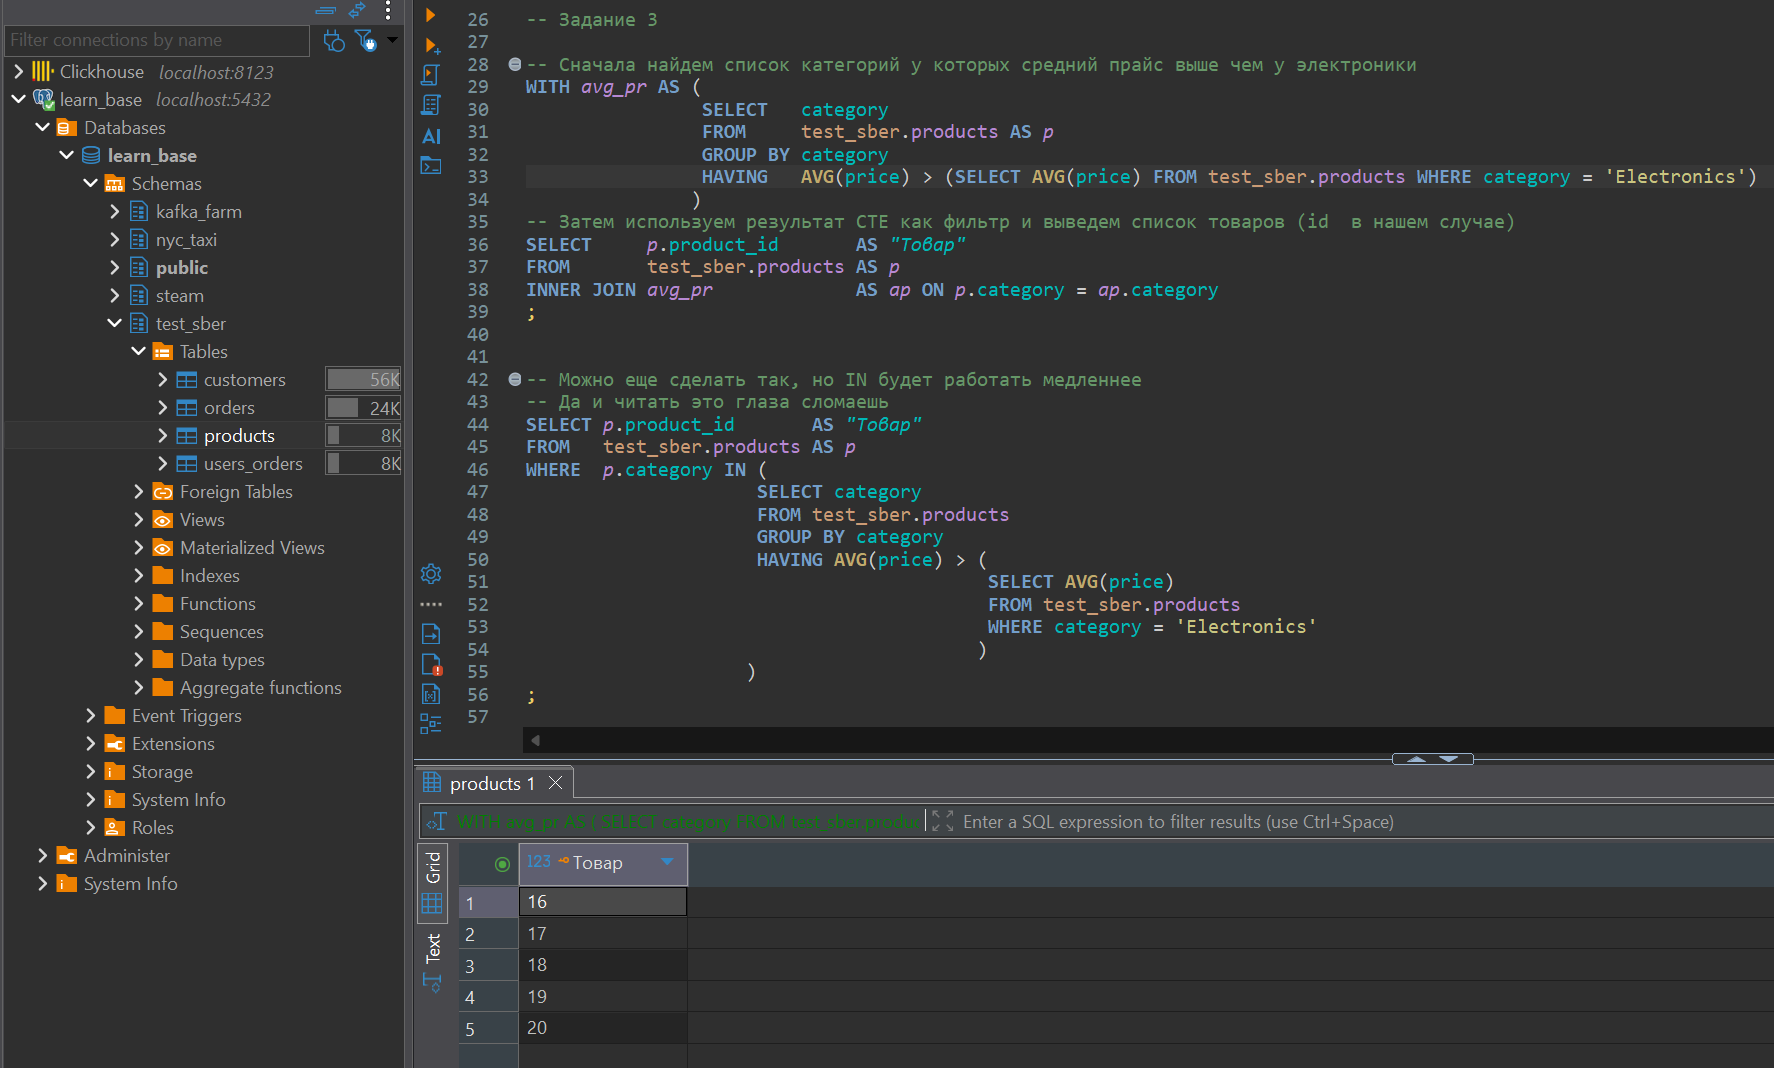

### Задача №4. 

Задача: Верните таблицу сотрудников с указанием среднего заработка сотрудника относительно отдела, сгруппированного по отделам.

Таблицы:
```sql
CREATE TABLE employees (
    employee_id INT PRIMARY KEY,
    department VARCHAR(50),
    salary DECIMAL(10, 2)
);
```

### Решение

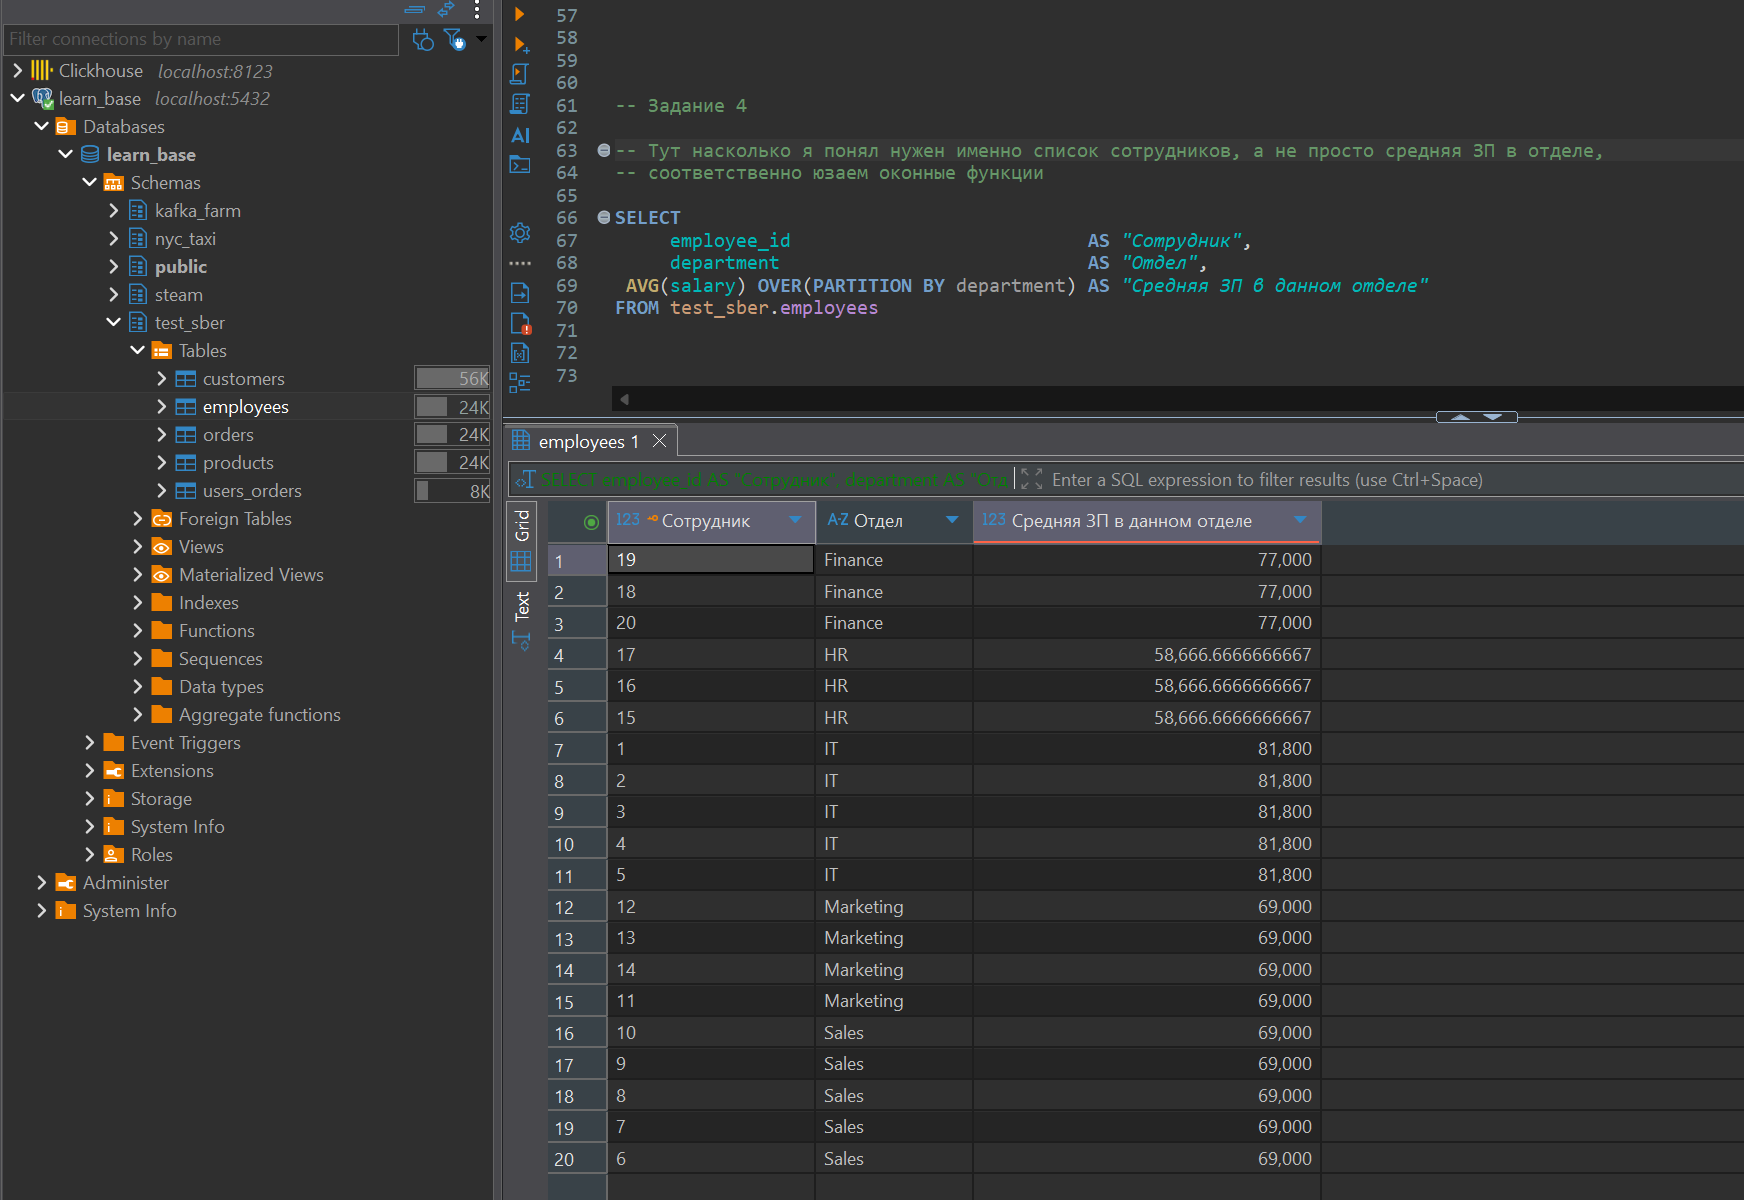

### Задача №5. 

Задача: Создать отчет, классифицирующий товары по категориям цен ('Дешевые', 'Средняя стоимость', 'Дорогие'), исходя из следующего условия:
- Если цена меньше 10 долларов — 'Дешевые'
- От 10 до 50 долларов включительно — 'Средняя стоимость'
- Больше 50 долларов — 'Дорогие'

Таблица:

```sql
CREATE TABLE goods (
    good_id INT PRIMARY KEY,
    name VARCHAR(100),
    price DECIMAL(10, 2)
);
```


### Решение

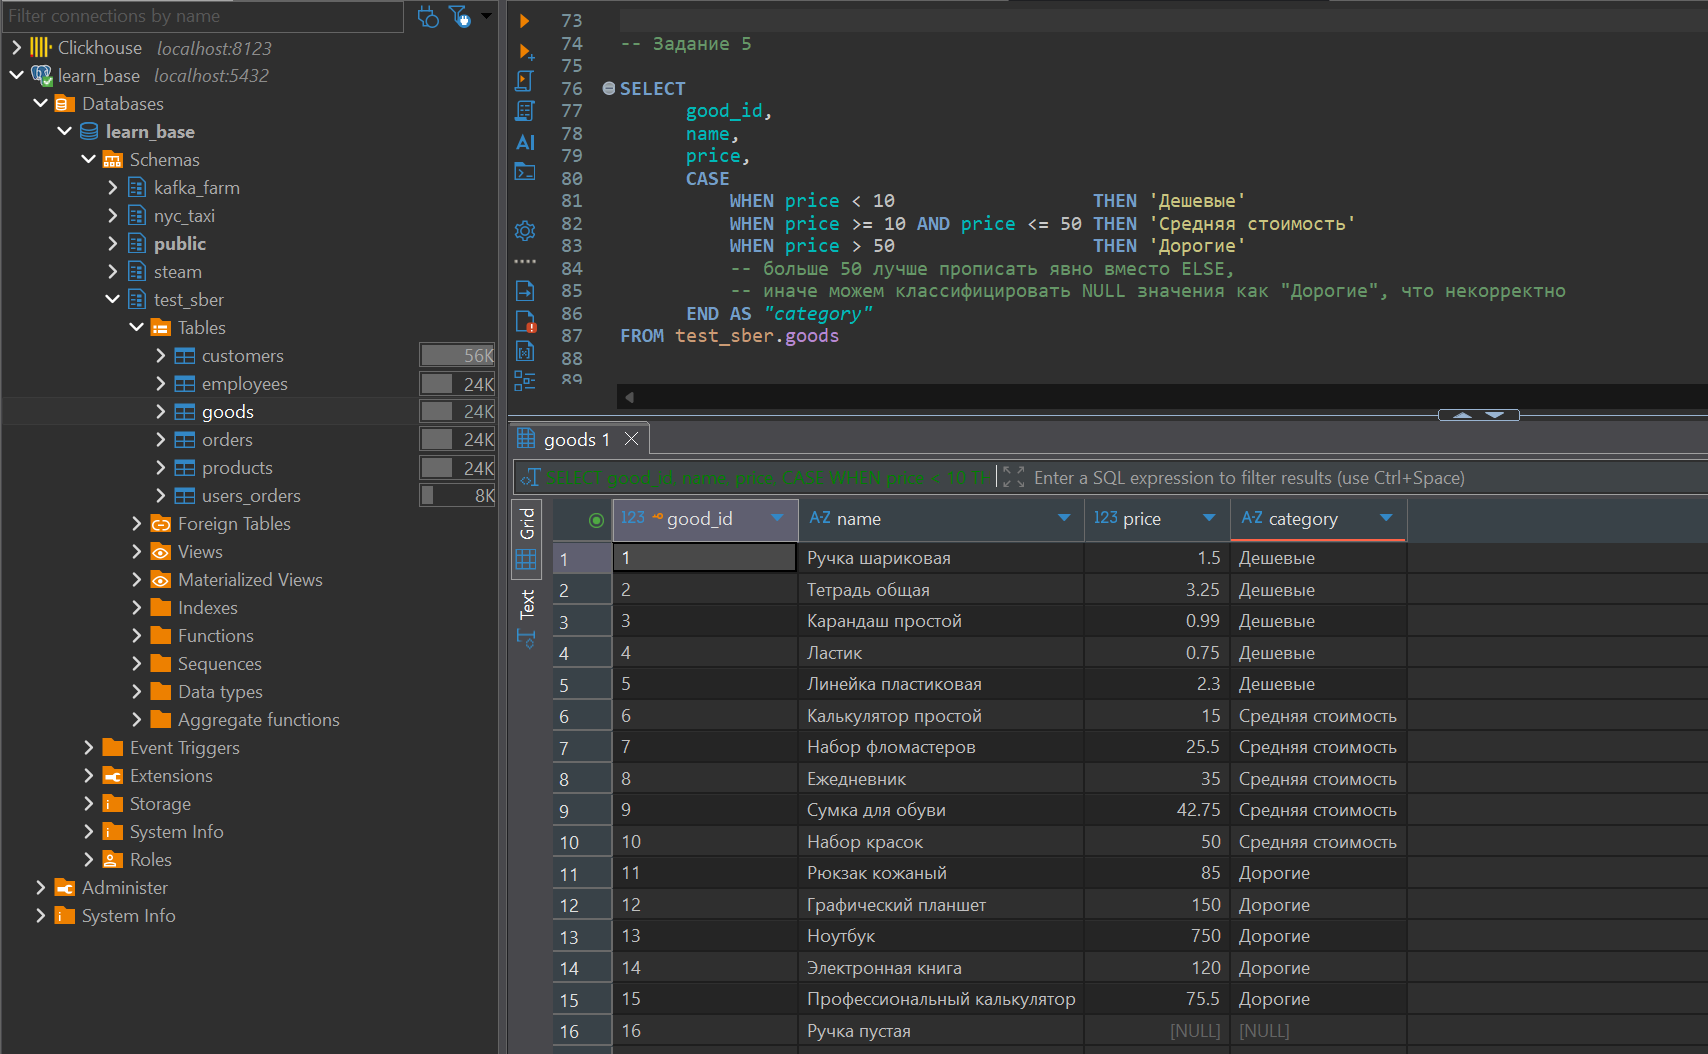

### Задача №6. Объединение временных интервалов (DATE DIFFERENCE)

Задача: Вычислить разницу в днях между датой регистрации клиента и сегодняшним днем.

Таблица:

```sql
CREATE TABLE clients (
    client_id INT PRIMARY KEY,
    registration_date DATE
);
```

### Решение

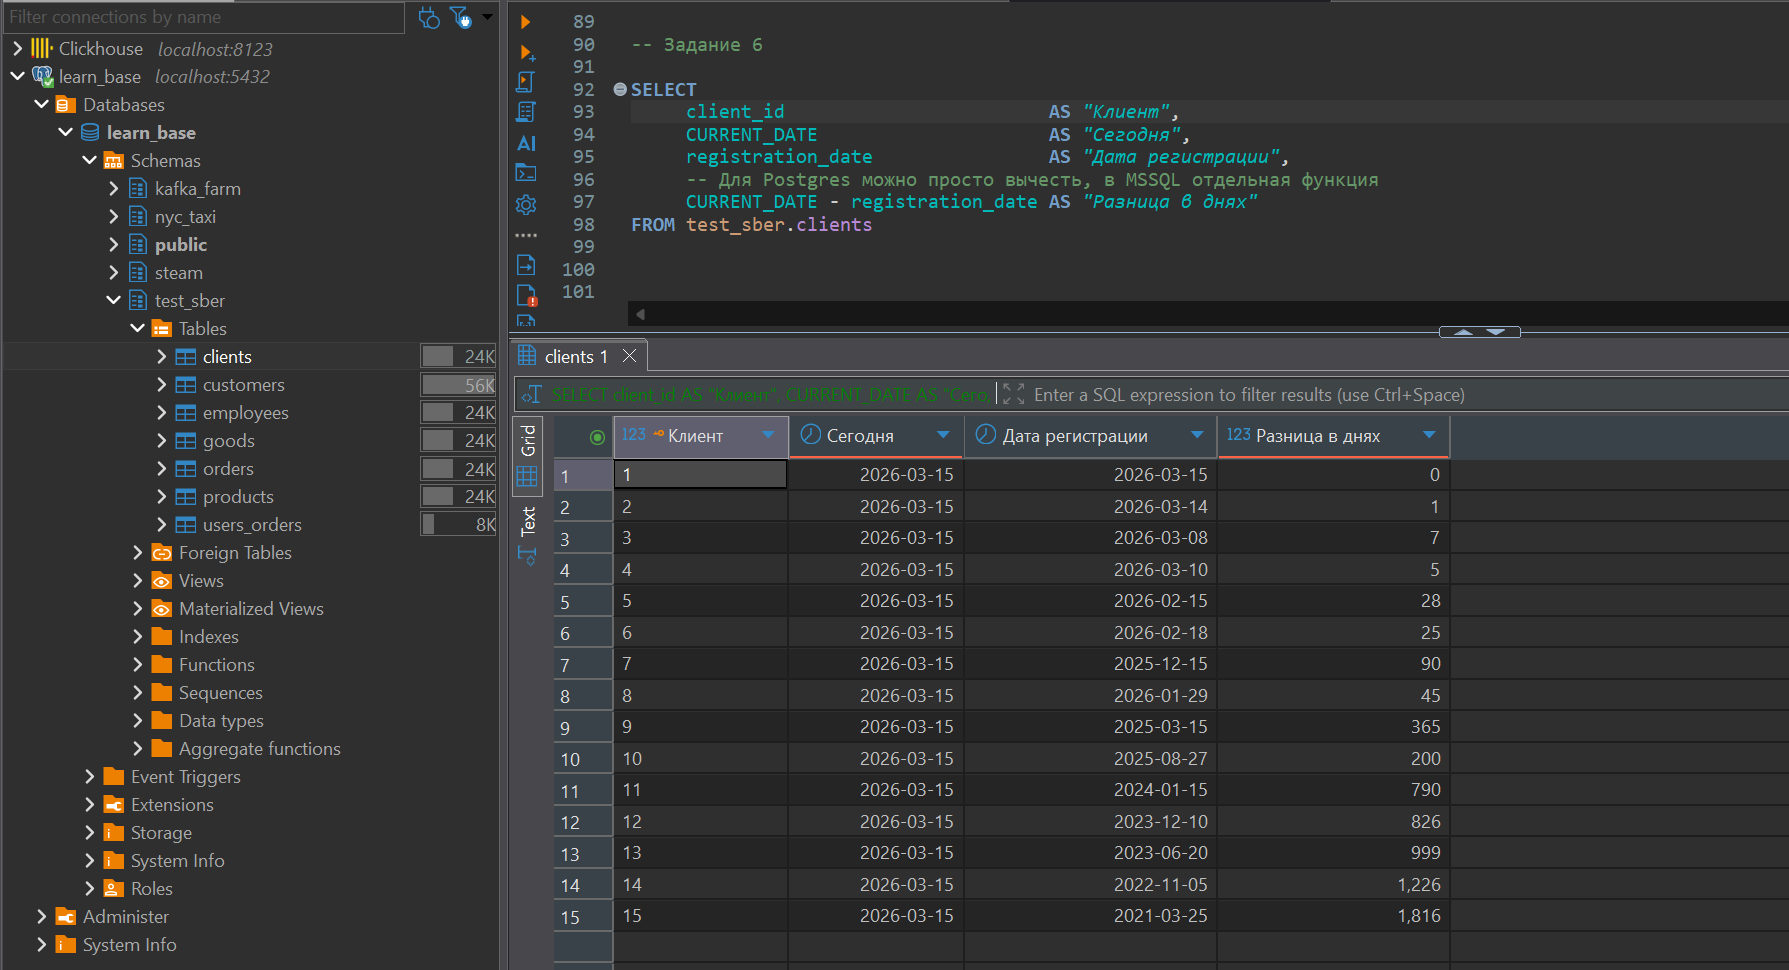

### Задача №7. 

Задача: Определить рост продаж каждого товара по сравнению с предыдущим месяцем.

Таблица:

```sql
CREATE TABLE sales (
    product_id INT,
    sale_month DATE,
    revenue DECIMAL(10, 2)
);
```

### Решение

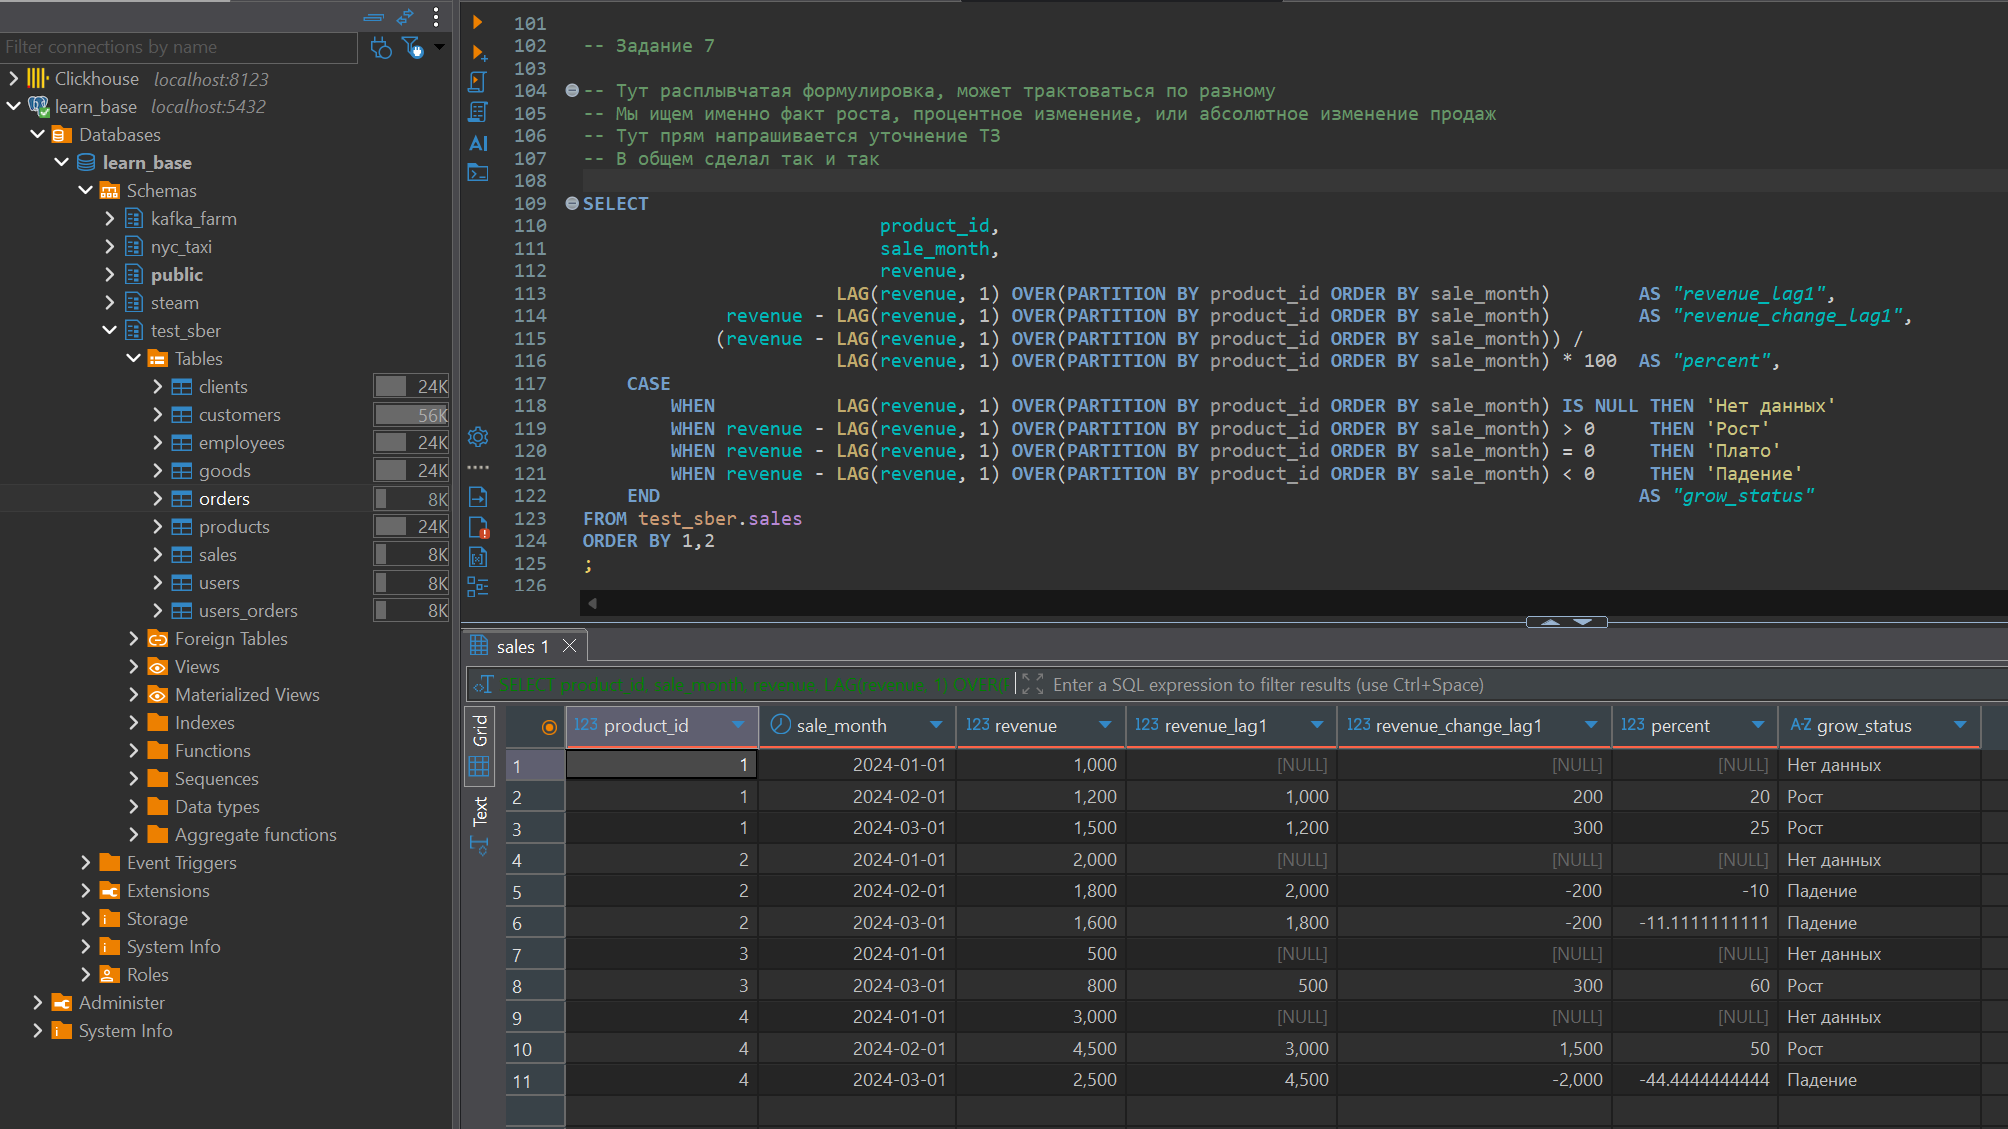

### Задача №8. 

Задача: Заполнить таблицу иерархии отделов рекурсивно, начиная с родительского отдела.

Таблица:

```sql
CREATE TABLE departments (
    dept_id INT PRIMARY KEY,
    parent_dept_id INT,
    dept_name VARCHAR(100)
);
```

### Решение

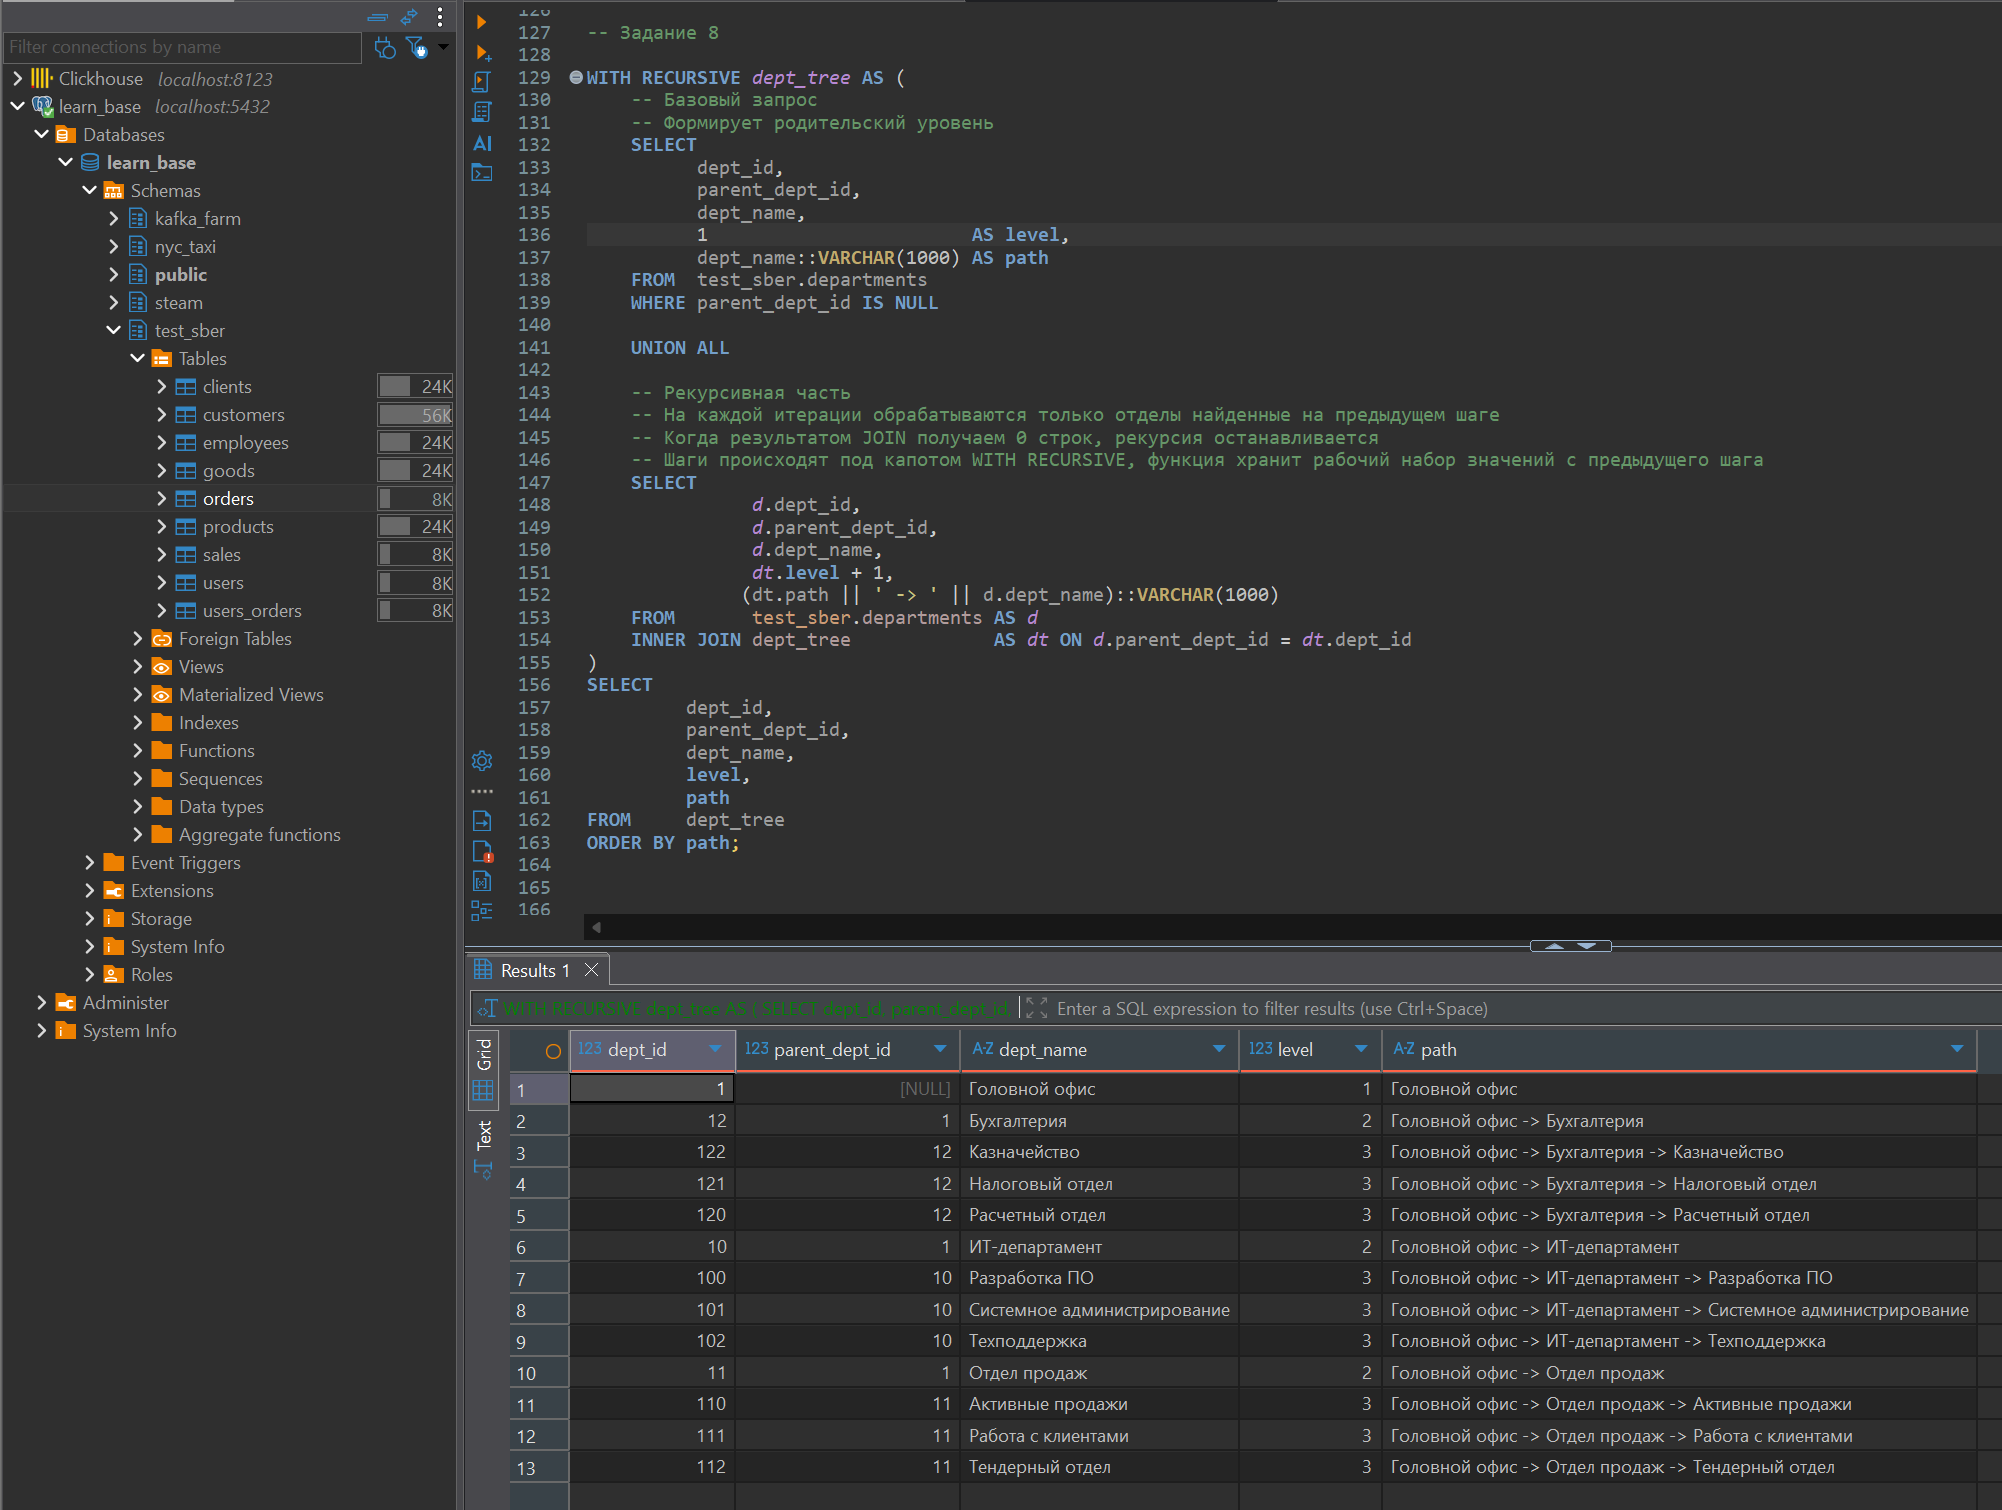

### Задача №9. 

Задача: Получить список пользователей, которые ни разу не делали заказы, вместе с информацией о последнем заказе каждого пользователя.

Таблицы:

```sql
CREATE TABLE users (
    user_id INT PRIMARY KEY,
    username VARCHAR(100)
);

CREATE TABLE orders (
    order_id INT PRIMARY KEY,
    user_id INT,
    order_date TIMESTAMP
);
```

### Решение

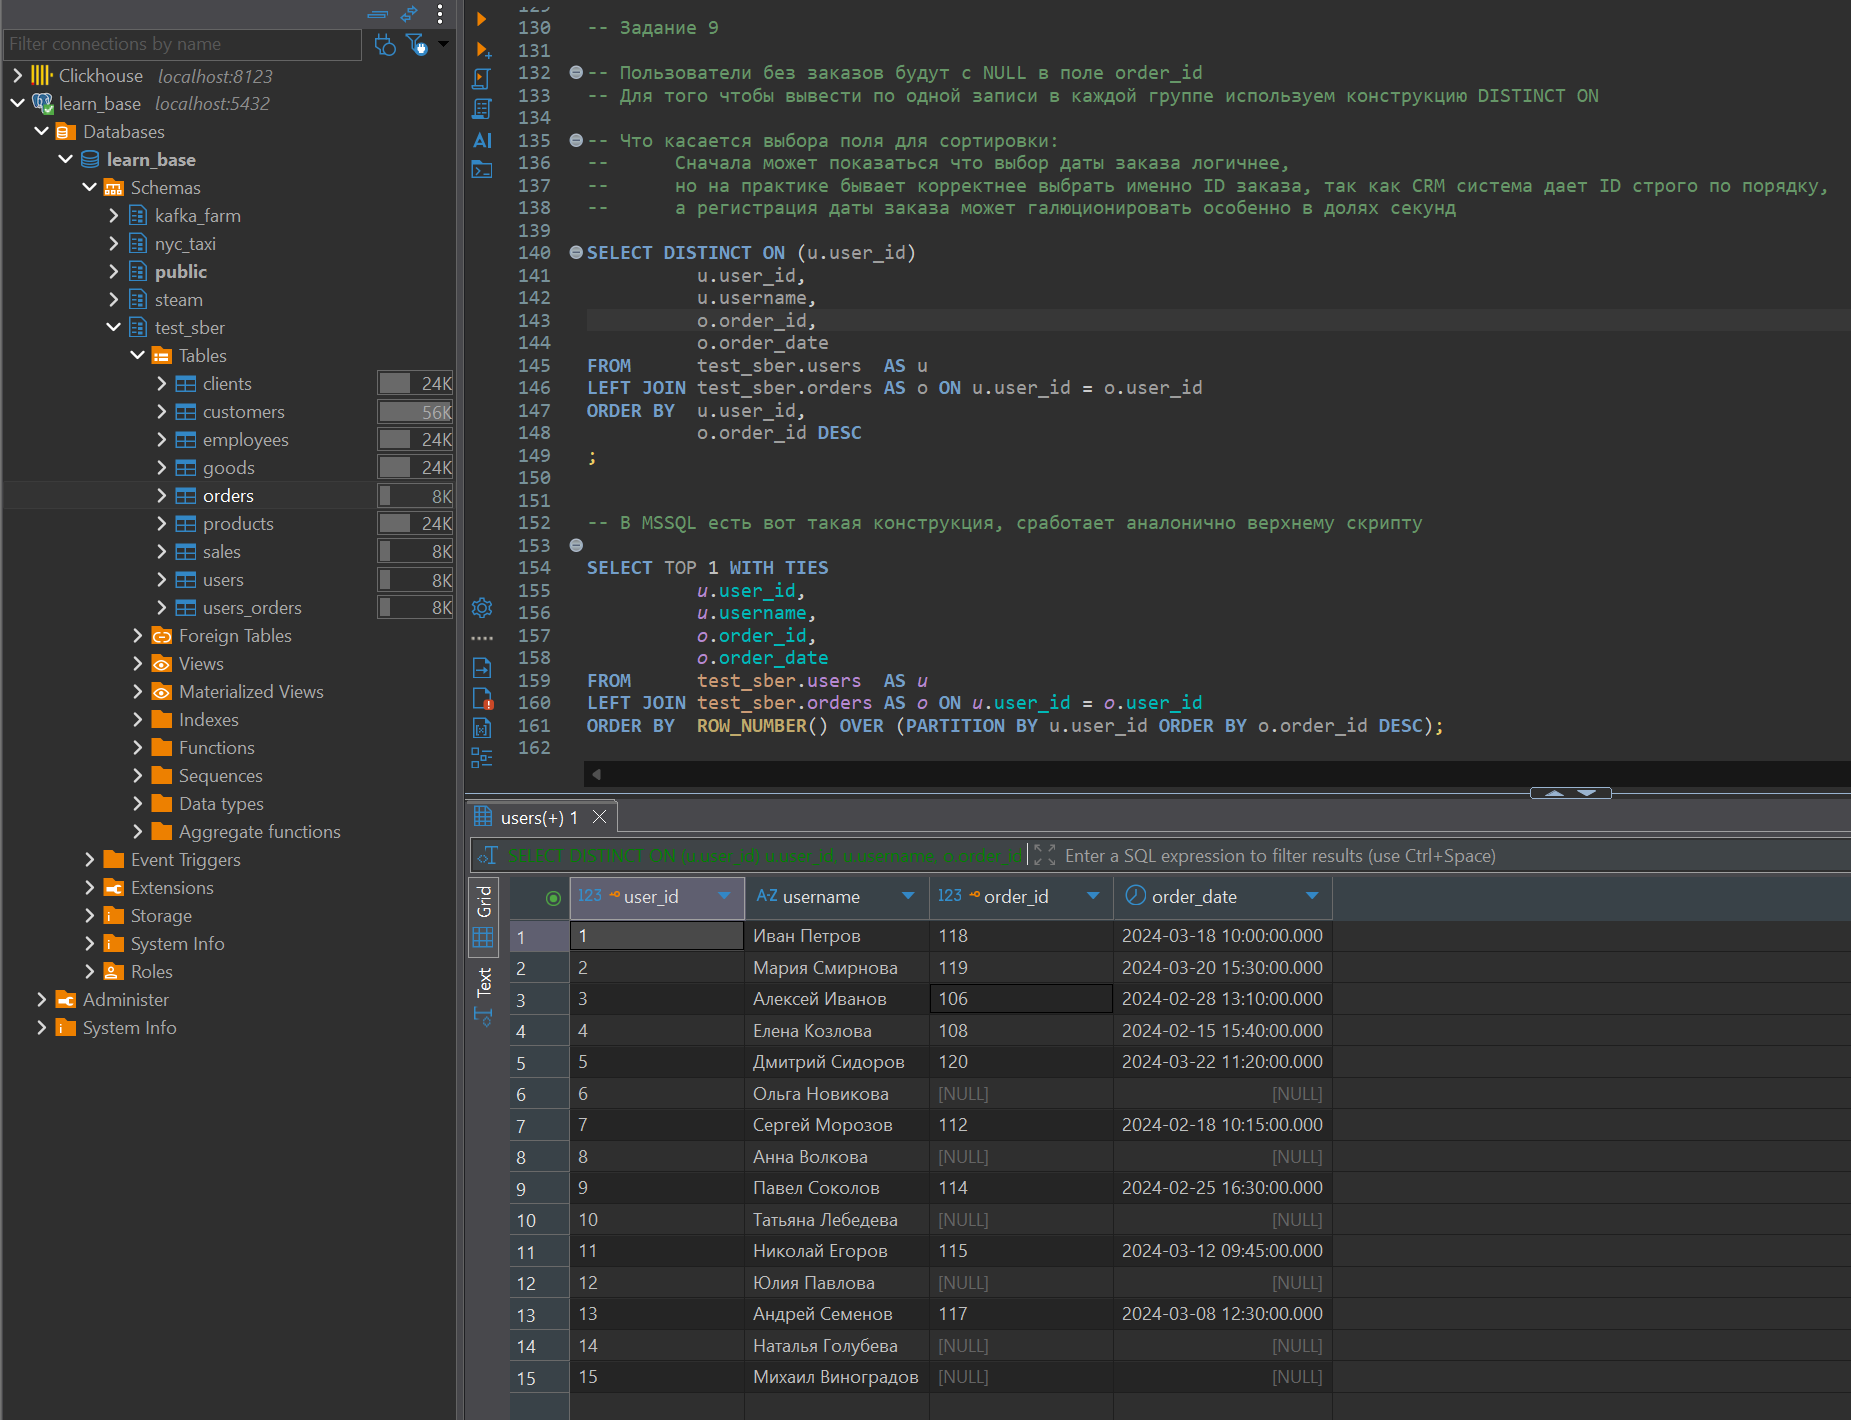

### Задача №10. 

Задача: Объяснить план выполнения следующего запроса:

```sql
SELECT 
           p.product_id, 
       SUM(s.revenue) AS total_revenue
FROM products p
JOIN sales s ON p.product_id = s.product_id
GROUP BY p.product_id
ORDER BY total_revenue DESC 
LIMIT 10;
```

Опишите структуру плана выполнения и предложите оптимизацию, если применимо.

### Решение

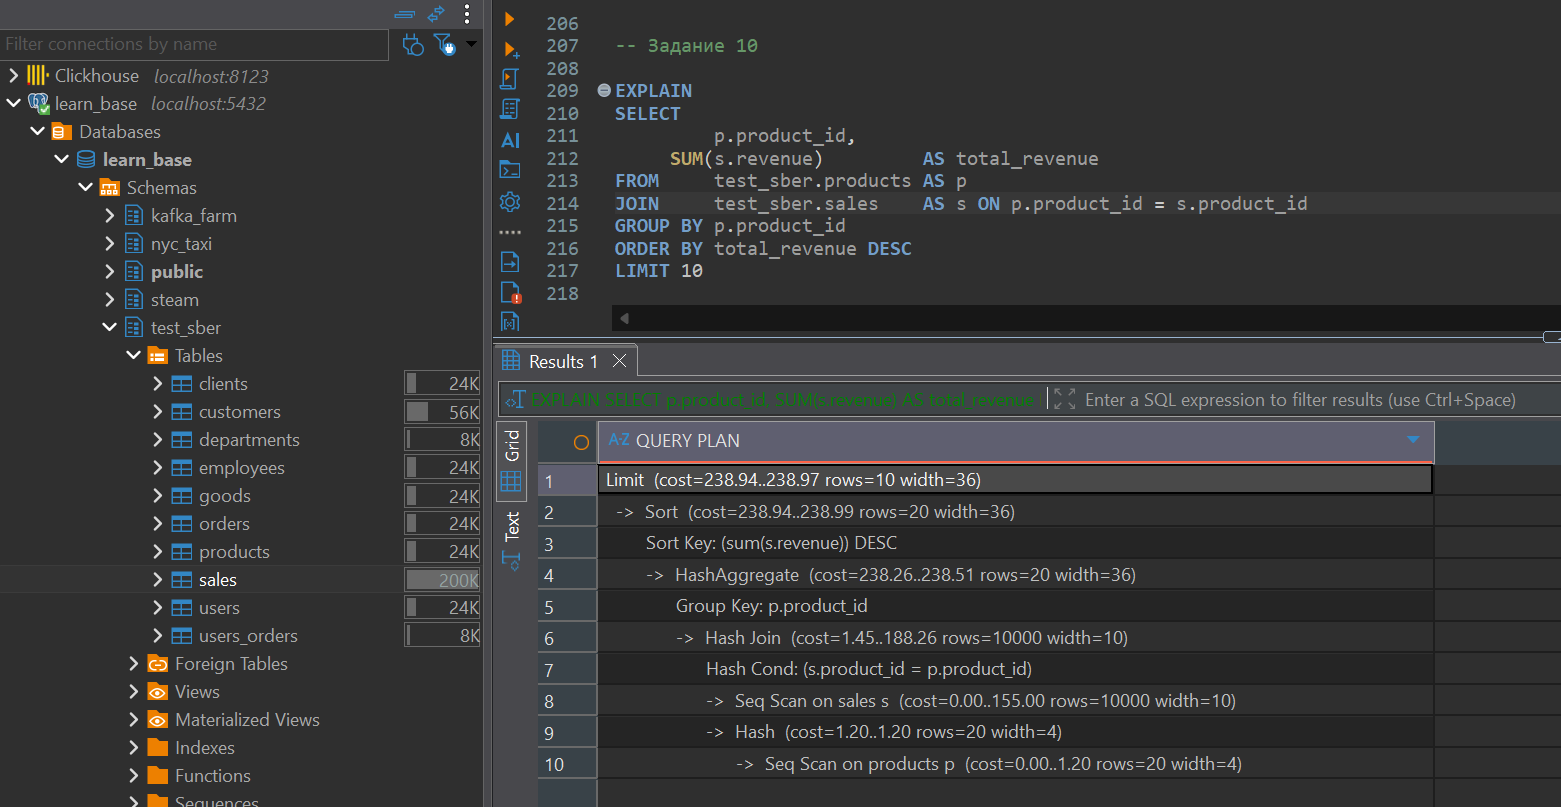

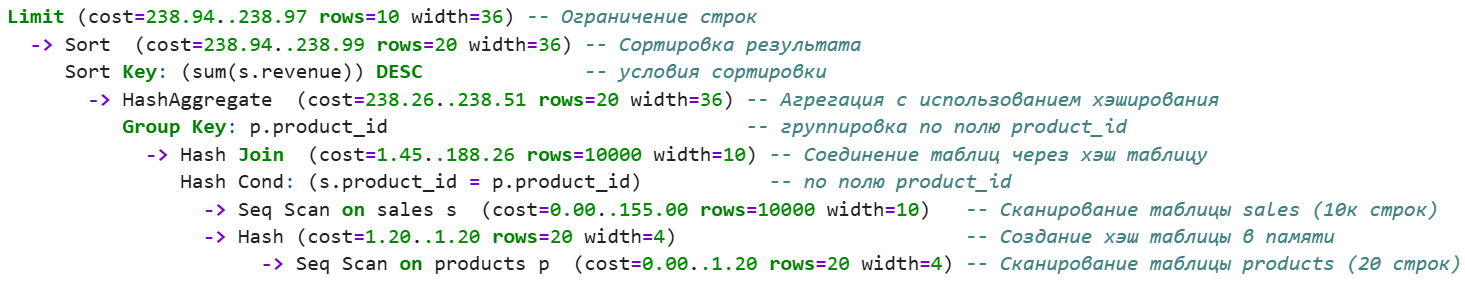

**Основные моменты**
 - Планировщик проигнорировал индексы на таблицах (хотя они были) и использовал полное сканирование. Ну, ему видимо виднее. Решил что фуллскан будет быстрее.
 - Самые дорогие операции:
     - сканирование sales (10 тыс строк): 155
     - соединение таблиц: 33
     - агрегация: 50

**Предложения по улучшению:**
- Основная проблема, что мы джойним огромную простыню к маленькой таблице.
- Соответсвенно, если сначала выполним агрегацию, а потом соединим две маленькие таблицы, получим прирост скорости за счет этой операции

Проверим

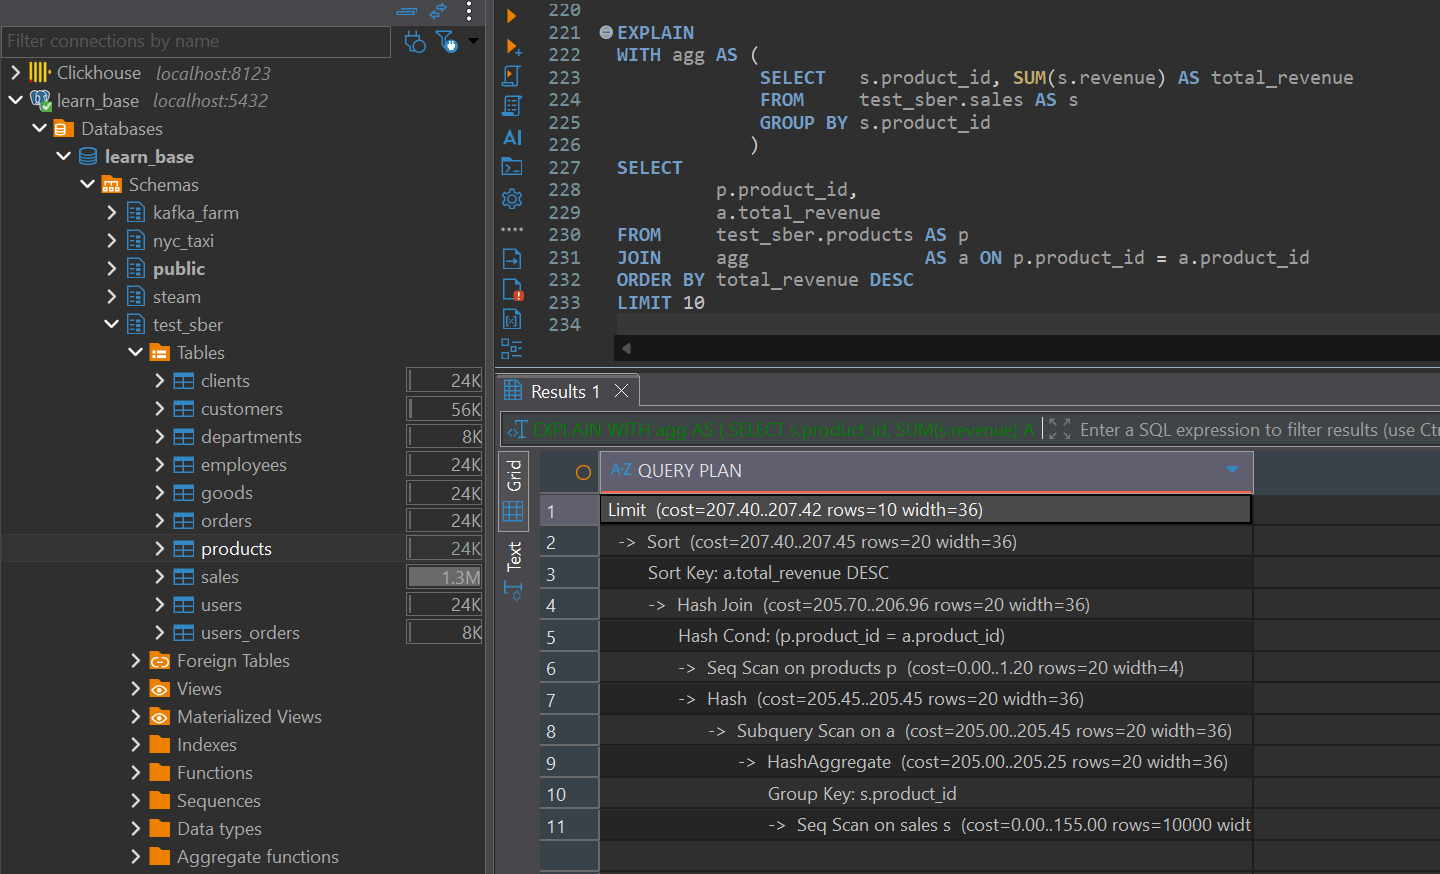

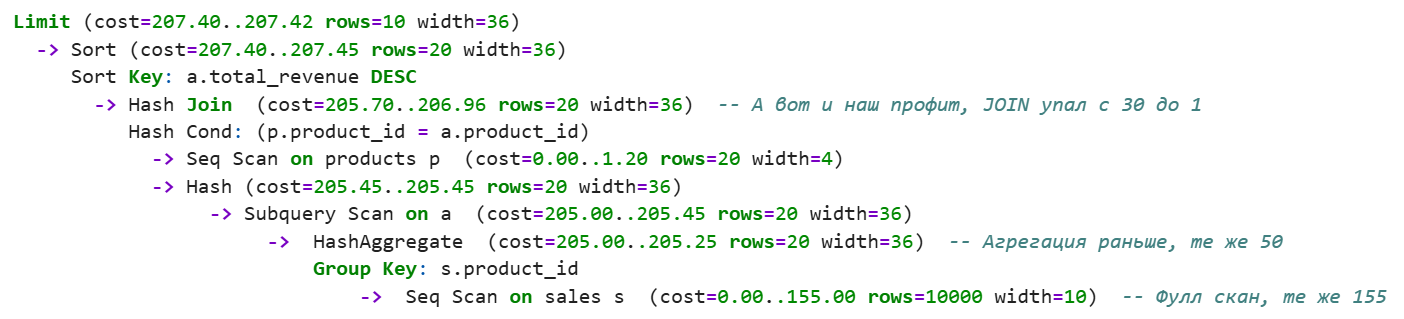

Как видим теория подтвердилась